In [56]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 함수 활용


In [4]:
def summary(df):
    print(f'데이터 세트: {df.shape}')
    summary = pd.DataFrame(df.dtypes, columns=['데이터 타입'])
    summary = summary.reset_index()  # 새로운 인덱스
    summary = summary.rename(columns={'index': '피처'})  # 열 이름 변경
    summary['결측값 수'] = df.isnull().sum().values  # 피처별 결측값 개수
    summary['고윳값 수'] = df.nunique().values  # 피처별 고윳값 개수
    return summary

In [5]:
def plot_one_box(df, col):
    plt.figure(figsize=(4,5))
    sns.boxplot(df[col])
    plt.title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

# 데이터

In [6]:
# 데이터 로드
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv('sample_submission.csv')

In [7]:
X = train.drop(columns='completed').copy()
y = train['completed'].copy()
test_x = test.copy()

In [8]:
summary(X)

데이터 세트: (748, 45)


,피처,데이터 타입,결측값 수,고윳값 수
0,ID,object,0,748
1,generation,int64,0,1
2,school1,int64,0,92
3,major type,object,22,3
4,major1_1,object,20,11
5,major1_2,object,439,10
6,major_data,bool,0,2
7,job,object,0,4
8,class1,int64,0,10
9,class2,float64,579,9


In [9]:
drop_col_na = X.columns[X.isnull().mean() >= 0.9].tolist()

In [10]:
drop_col_na

['class3', 'class4', 'contest_award', 'contest_participation', 'idea_contest']

In [11]:
X = X.drop(columns = drop_col_na)
test_x = test_x.drop(columns = drop_col_na)

In [12]:
X = X.drop(columns = ['ID','generation'])
test_x = test_x.drop(columns = ['ID','generation'])

In [13]:
# 데이터 확인
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 38 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   school1                          748 non-null    int64  
 1   major type                       726 non-null    object 
 2   major1_1                         728 non-null    object 
 3   major1_2                         309 non-null    object 
 4   major_data                       748 non-null    bool   
 5   job                              748 non-null    object 
 6   class1                           748 non-null    int64  
 7   class2                           169 non-null    float64
 8   re_registration                  748 non-null    object 
 9   nationality                      747 non-null    object 
 10  inflow_route                     748 non-null    object 
 11  whyBDA                           748 non-null    object 
 12  what_to_gain          

#데이터 정리

In [14]:
cat_col = X.select_dtypes(include=['object','bool']).columns.tolist()
num_col = X.select_dtypes(exclude=['object','bool']).columns.tolist()

In [15]:
for c in cat_col :
  X[c] = X[c].fillna('na')
  test_x[c] = test_x[c].fillna('na')

In [16]:
for c in num_col :
  X[c] = X[c].fillna(0)
  test_x[c] = test_x[c].fillna(0)

In [17]:
num_col

['school1', 'class1', 'class2', 'completed_semester', 'time_input']

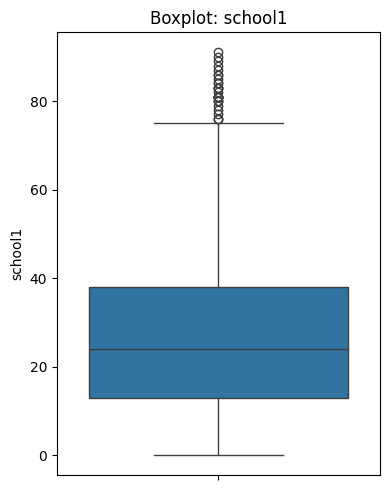

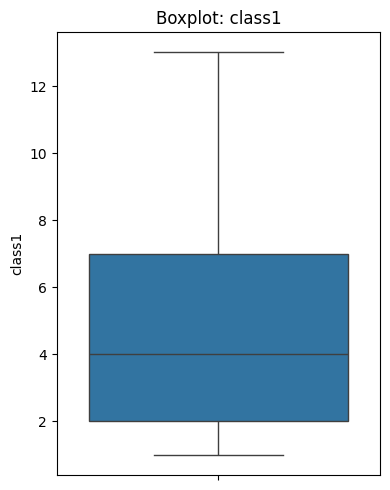

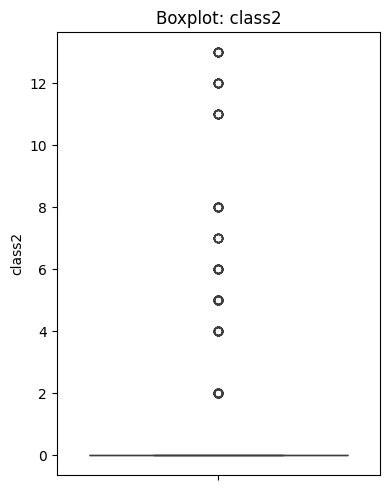

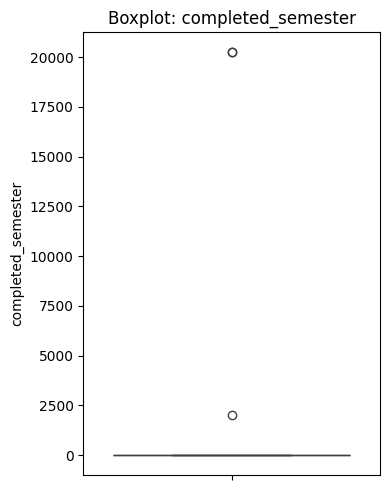

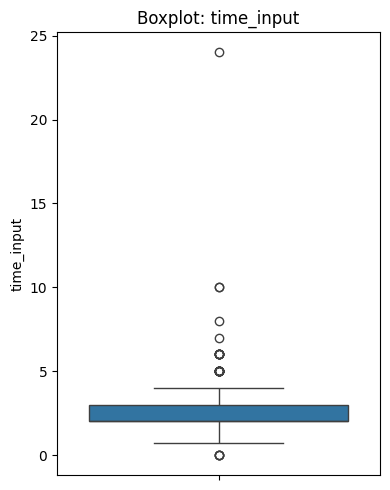

In [19]:
for i in num_col :
  plot_one_box(X,i)  # 타깃명 맞게 수정

In [20]:
X['completed_semester'].value_counts()

completed_semester
6.00        205
8.00        193
4.00        134
7.00         74
5.00         40
2.00         29
0.00         29
9.00         20
3.00         10
10.00         9
20241.00      2
1.00          2
2020.02       1
Name: count, dtype: int64

In [21]:
test_x['completed_semester'].value_counts()

completed_semester
5.0     170
7.0     168
8.0     154
6.0      90
0.0      74
3.0      63
4.0      41
9.0      30
2.0      11
10.0      9
1.0       4
Name: count, dtype: int64

In [22]:
if "completed_semester" in X.columns:
    med = X["completed_semester"].median()
    X["completed_semester"] = X["completed_semester"].replace({20241.0: med,2020.02:med})

In [23]:
med = X["time_input"].median()
X["time_input"] = X["time_input"].replace({24.0: med})

In [24]:
X['time_input'].value_counts()

time_input
2.0     396
3.0     121
1.0     117
4.0      58
5.0      20
1.5      17
6.0       8
0.0       4
10.0      2
2.5       2
0.7       1
7.0       1
8.0       1
Name: count, dtype: int64

In [25]:
test_x['time_input'].value_counts()

time_input
2.0     323
3.0     193
1.0     149
4.0      63
5.0      38
6.0      15
1.5      11
10.0      5
8.0       4
0.5       3
2.5       3
0.0       2
7.0       2
12.0      2
0.8       1
Name: count, dtype: int64

# 데이터 변환 및 스케일링

In [26]:
cat_col = X.select_dtypes(include=['object','bool']).columns.tolist()
num_col = X.select_dtypes(exclude=['object','bool']).columns.tolist()

In [27]:
print(cat_col)

['major type', 'major1_1', 'major1_2', 'major_data', 'job', 're_registration', 'nationality', 'inflow_route', 'whyBDA', 'what_to_gain', 'hope_for_group', 'previous_class_3', 'previous_class_4', 'previous_class_5', 'previous_class_6', 'previous_class_7', 'previous_class_8', 'major_field', 'desired_career_path', 'project_type', 'desired_job', 'certificate_acquisition', 'desired_certificate', 'desired_job_except_data', 'incumbents_level', 'incumbents_lecture', 'incumbents_company_level', 'incumbents_lecture_type', 'incumbents_lecture_scale', 'incumbents_lecture_scale_reason', 'interested_company', 'expected_domain', 'onedayclass_topic']


In [28]:
print(num_col)

['school1', 'class1', 'class2', 'completed_semester', 'time_input']


In [29]:
for c in cat_col :
  encoder = LabelEncoder()

  X[c] = X[c].astype(str)
  test_x[c] = test_x[c].astype(str)

  encoder.fit(X[c])

  X[c] = encoder.transform(X[c])

  encoder.fit(test_x[c])

  test_x[c] = encoder.transform(test_x[c])

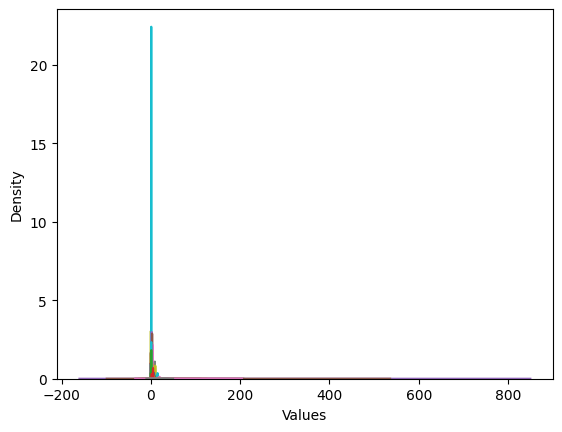

In [30]:
fig, ax = plt.subplots()

for j in range(X.shape[1]):
    ax = sns.kdeplot(X.iloc[:, j], ax=ax, label=f'feature{j}')

ax.set_ylabel('Density')
ax.set_xlabel('Values')
plt.show()

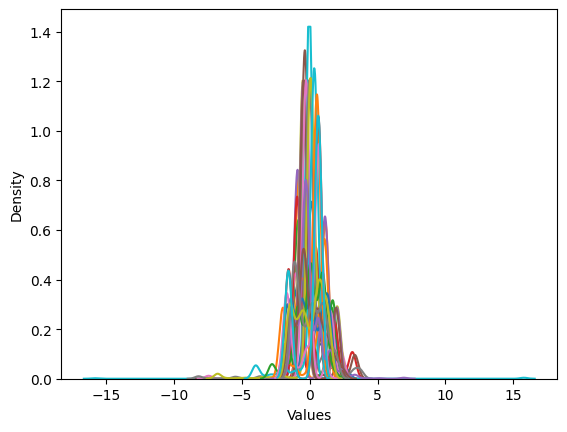

In [42]:
scaler = StandardScaler()
X_scaled_st = scaler.fit_transform(X)

X_scaled_st = pd.DataFrame(
    X_scaled_st,
    columns=X.columns,
    index=X.index
)

fig, ax = plt.subplots()

for j in range(30):
    ax = sns.kdeplot(X_scaled_st.iloc[:, j], ax=ax, label=f'feature{j}')

ax.set_ylabel('Density')
ax.set_xlabel('Values')
plt.show()

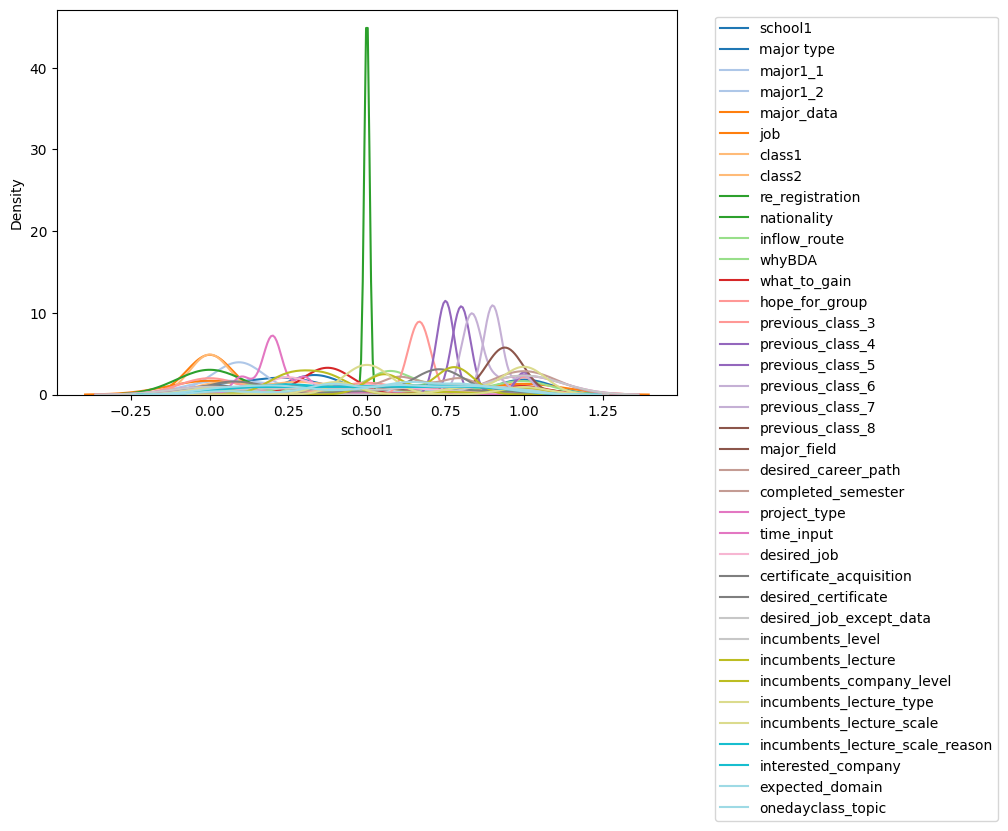

<Figure size 3000x3000 with 0 Axes>

In [35]:
MinMax = MinMaxScaler()
X_scaled_mm = MinMax.fit_transform(X)

X_scaled_mm = pd.DataFrame(
    X_scaled_mm,
    columns=X.columns,
    index=X.index
)

n_features = X_scaled_mm.shape[1]
colors = plt.cm.tab20(np.linspace(0, 1, n_features))

fig, ax = plt.subplots(figsize=(8,5))

for j in range(n_features):
    col_name = X_scaled_mm.columns[j]
    sns.kdeplot(
        X_scaled_mm.iloc[:, j],
        ax=ax,
        label=col_name,
        color=colors[j]
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.figure(figsize=(30, 30))
plt.tight_layout()
plt.show()


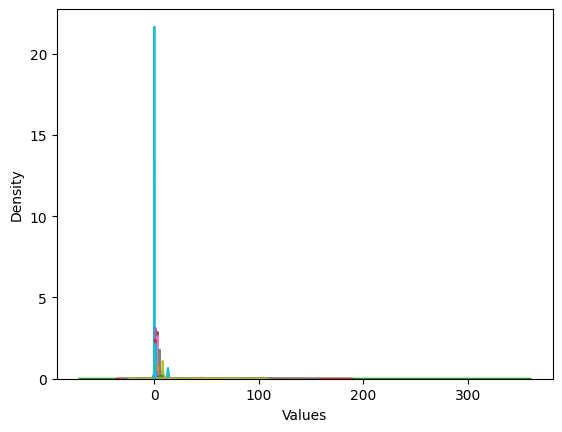

In [39]:
fig, ax = plt.subplots()

for j in range(30):
    ax = sns.kdeplot(test_x.iloc[:, j], ax=ax, label=f'feature{j}')

ax.set_ylabel('Density')
ax.set_xlabel('Values')
plt.show()

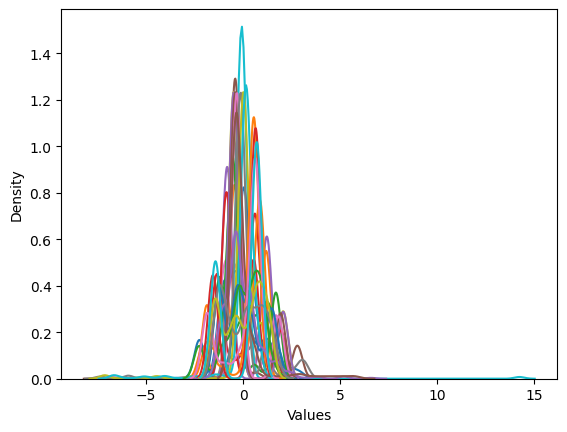

In [43]:
scaler = StandardScaler()
test_x_scaled_st = scaler.fit_transform(test_x)

test_x_scaled_st = pd.DataFrame(
    test_x_scaled_st,
    columns=test_x.columns,
    index=test_x.index
)

fig, ax = plt.subplots()

for j in range(30):
    ax = sns.kdeplot(test_x_scaled_st.iloc[:, j], ax=ax, label=f'feature{j}')

ax.set_ylabel('Density')
ax.set_xlabel('Values')
plt.show()

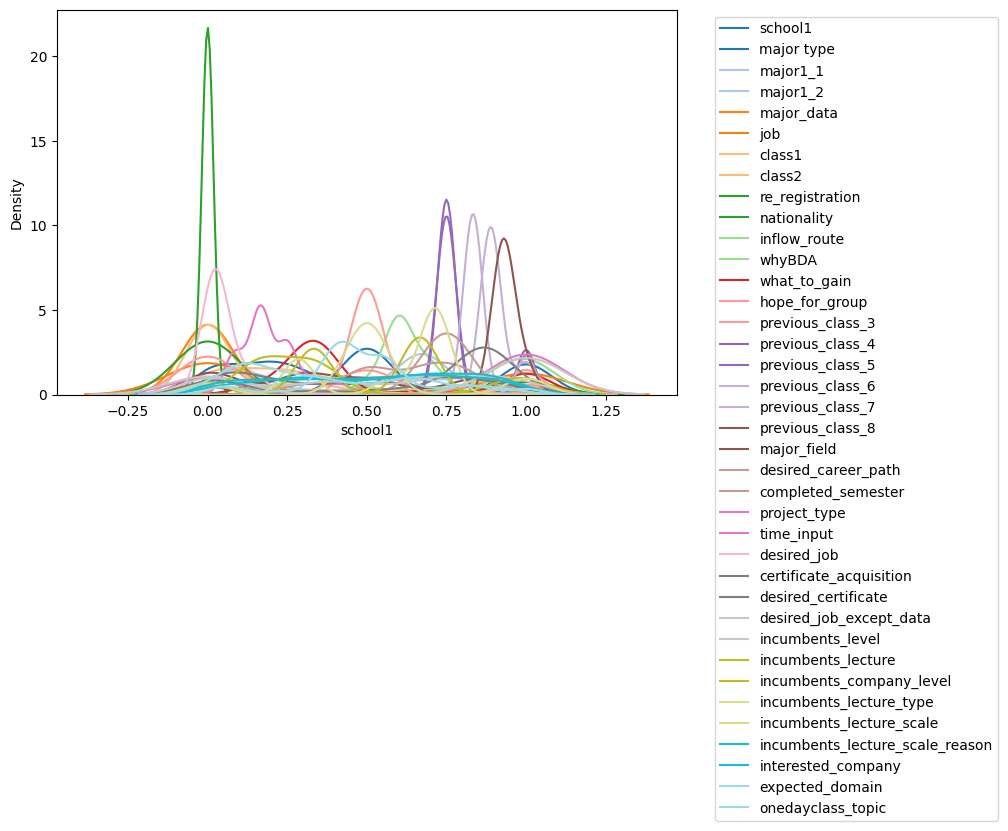

<Figure size 3000x1800 with 0 Axes>

In [45]:
MinMax = MinMaxScaler()
test_x_scaled_mm = MinMax.fit_transform(test_x)

test_x_scaled_mm = pd.DataFrame(
    test_x_scaled_mm,
    columns=test_x.columns,
    index=test_x.index
)

n_features = test_x_scaled_mm.shape[1]
colors = plt.cm.tab20(np.linspace(0, 1, n_features))

fig, ax = plt.subplots(figsize=(8,5))

for j in range(n_features):
    col_name = X.columns[j]
    sns.kdeplot(
        test_x_scaled_mm.iloc[:, j],
        ax=ax,
        label=col_name,
        color=colors[j]
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.figure(figsize=(30,18))
plt.tight_layout()
plt.show()


# 불필요 열 제거

<Axes: >

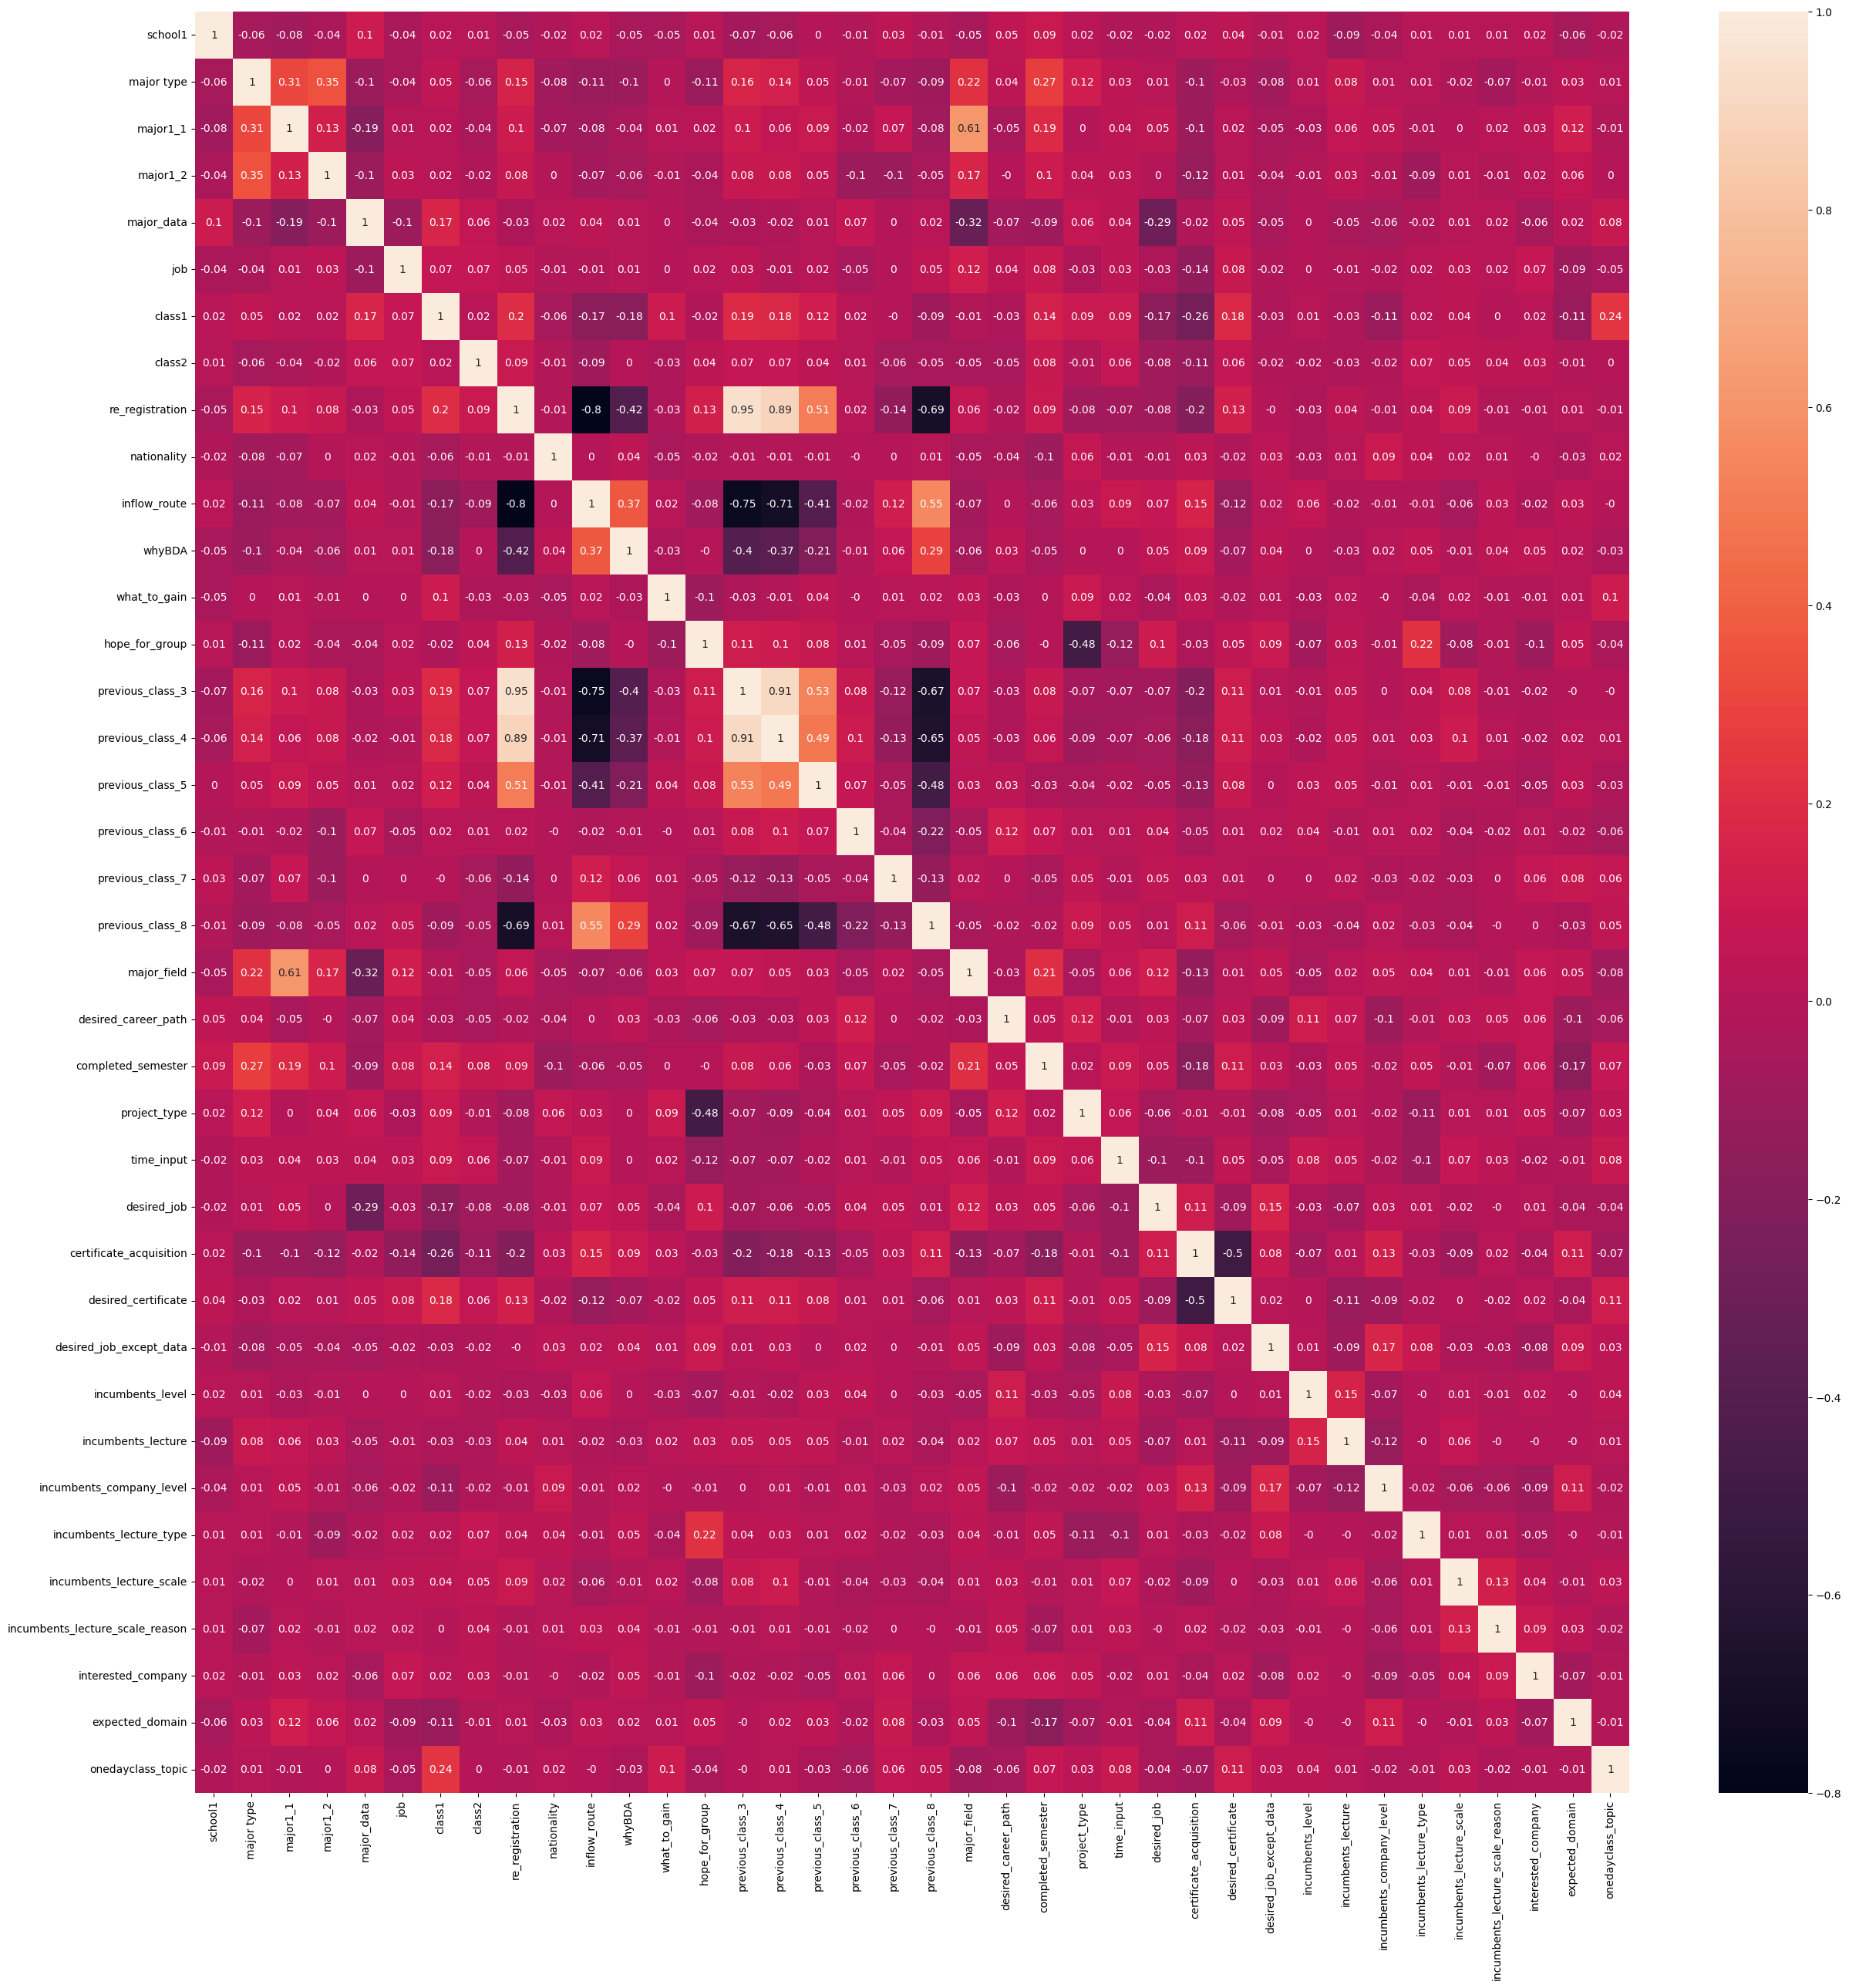

In [47]:
plt.figure(figsize=(30,30))
sns.heatmap(X_scaled_mm.corr().round(2), annot = True)

In [49]:
drop_col = ['re_registration','inflow_route','previous_class_3','previous_class_4','previous_class_8','major_field']
X_scaled_mm = X_scaled_mm.drop(columns=drop_col)
test_x_scaled_mm = test_x_scaled_mm.drop(columns=drop_col)

<Axes: >

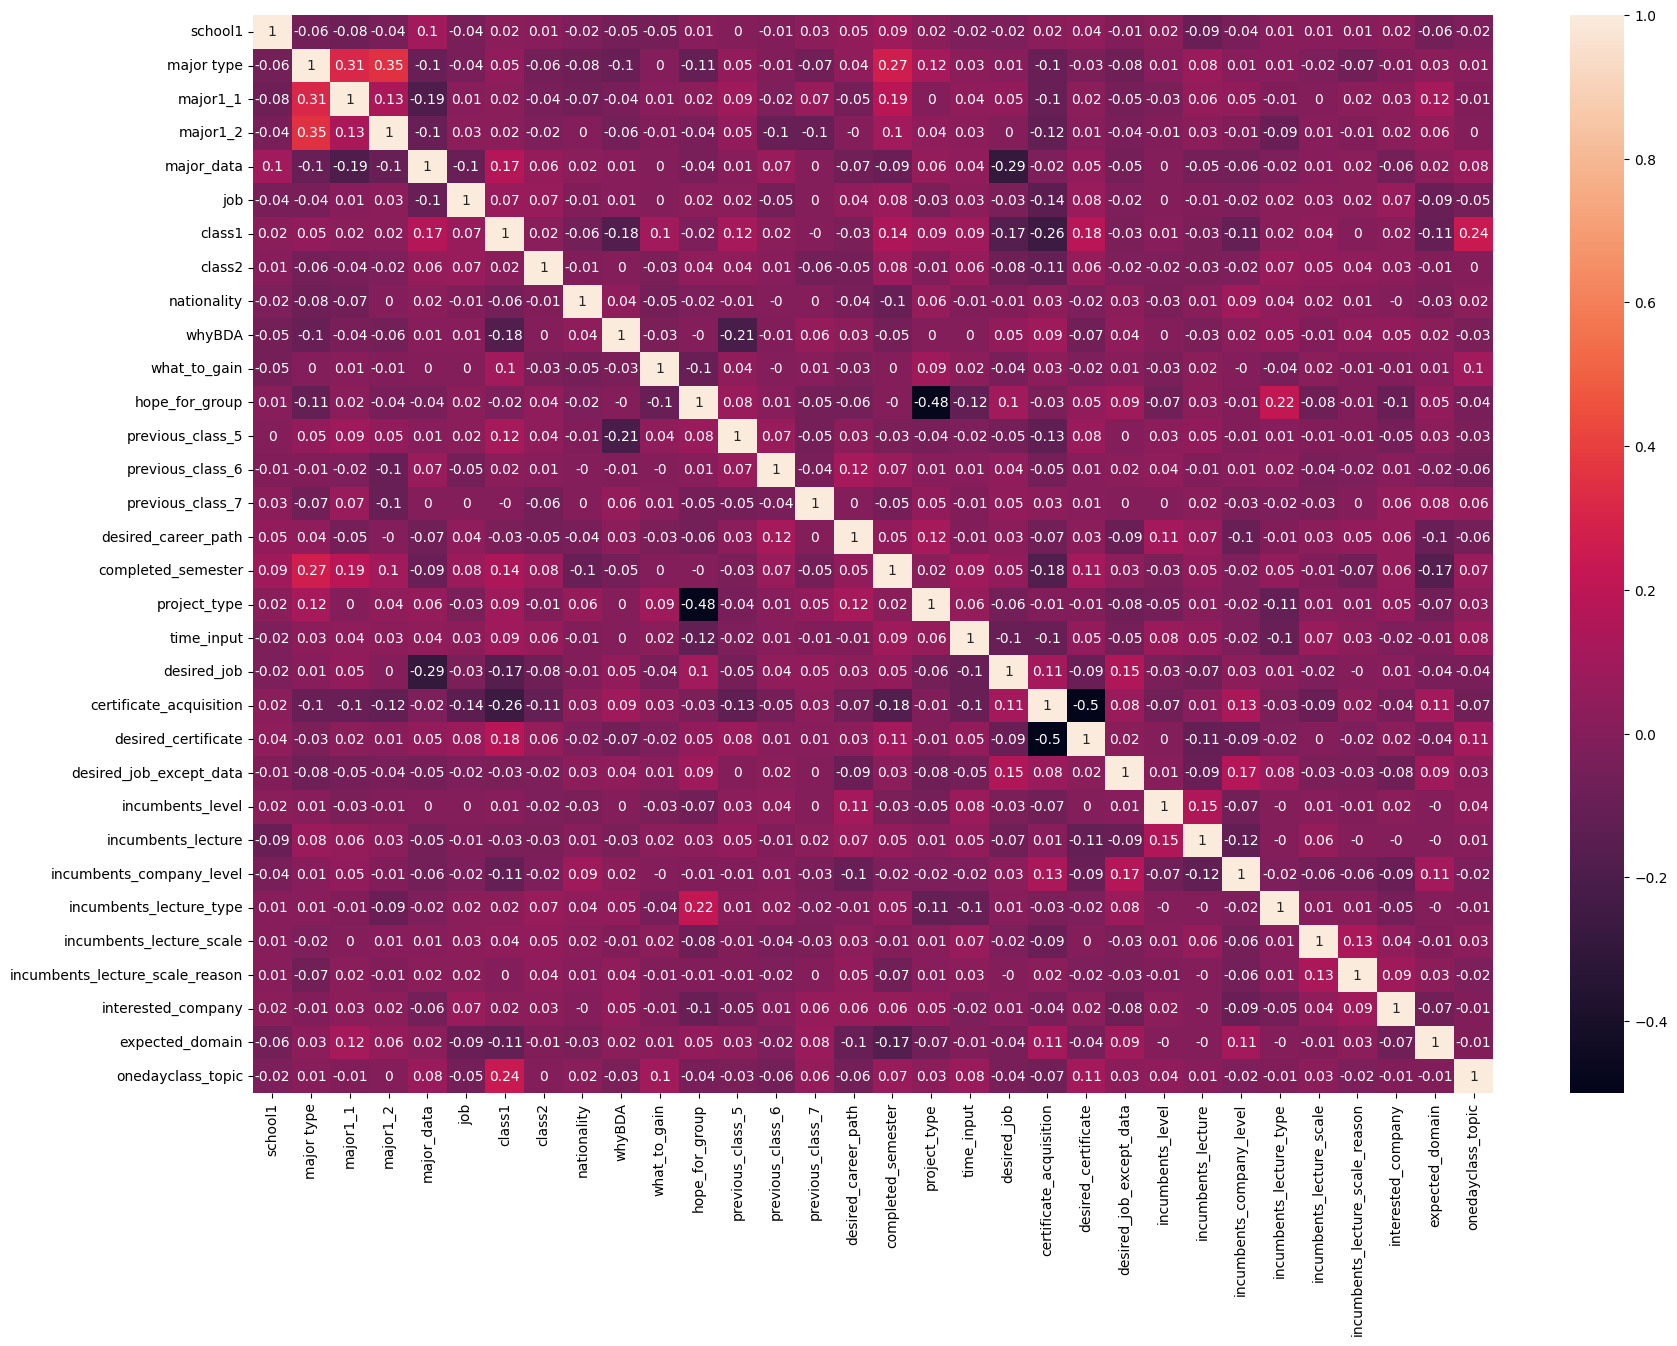

In [50]:
plt.figure(figsize=(20,14))
sns.heatmap(X_scaled_mm.corr().round(2), annot = True)

#CatBoost

In [51]:
# 모델 설정 및 교차 검증
n_splits = 5

skf = StratifiedKFold(n_splits=n_splits, shuffle= True, random_state=42)

oof_preds = np.zeros(len(X_scaled_mm))
test_preds = np.zeros(len(test_x_scaled_mm))


model = CatBoostClassifier(
    random_seed=42
    )

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_scaled_mm, y), start=1):
    X_tr, X_va = X_scaled_mm.iloc[tr_idx], X_scaled_mm.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    train_pool = Pool(X_tr, y_tr)
    val_pool = Pool(X_va, y_va)
    test_pool = Pool(test_x_scaled_mm)

    model.fit(train_pool, eval_set=val_pool)

    oof_preds[va_idx] = model.predict_proba(val_pool)[:, 1]
    test_preds += model.predict_proba(test_pool)[:, 1] / n_splits

Learning rate set to 0.02791
0:	learn: 0.6874955	test: 0.6889628	best: 0.6889628 (0)	total: 187ms	remaining: 3m 6s
1:	learn: 0.6793119	test: 0.6838141	best: 0.6838141 (1)	total: 189ms	remaining: 1m 34s
2:	learn: 0.6735776	test: 0.6792409	best: 0.6792409 (2)	total: 191ms	remaining: 1m 3s
3:	learn: 0.6675654	test: 0.6750928	best: 0.6750928 (3)	total: 193ms	remaining: 48.1s
4:	learn: 0.6622248	test: 0.6702534	best: 0.6702534 (4)	total: 195ms	remaining: 38.9s
5:	learn: 0.6550872	test: 0.6663508	best: 0.6663508 (5)	total: 197ms	remaining: 32.7s
6:	learn: 0.6508676	test: 0.6626609	best: 0.6626609 (6)	total: 199ms	remaining: 28.3s
7:	learn: 0.6466307	test: 0.6594716	best: 0.6594716 (7)	total: 201ms	remaining: 24.9s
8:	learn: 0.6427300	test: 0.6560993	best: 0.6560993 (8)	total: 203ms	remaining: 22.4s
9:	learn: 0.6385660	test: 0.6520440	best: 0.6520440 (9)	total: 205ms	remaining: 20.3s
10:	learn: 0.6319870	test: 0.6487440	best: 0.6487440 (10)	total: 207ms	remaining: 18.6s
11:	learn: 0.6254213	t

In [52]:
best_t, best_f1 = 0.5, -1.0
for t in np.linspace(0.01, 0.99, 199):
    pred = (oof_preds >= t).astype(int)
    f1 = f1_score(y, pred)
    if f1 > best_f1:
        best_f1, best_t = f1, float(t)

print(f"[OOF] best_f1={best_f1:.6f}, best_t={best_t:.3f}, oof_pred_pos_rate={(oof_preds>=best_t).mean():.3f}")


[OOF] best_f1=0.473480, best_t=0.253, oof_pred_pos_rate=0.735


# 제출

In [53]:
prediction = (test_preds > best_t).astype(int)

In [55]:
sample_submission['completed'] = prediction
sample_submission.to_csv("submission_cb.csv",index=False)